# Road network in Styria, 2015–2025

Descriptive analysis for the master's thesis. A street is an OSM road segment (`highway` tag); a motorway is a segment tagged `motorway`.

**Sources:** `OGD/GIP/*.osm.pbf`; `OGD/Gemeindegrenzen.zip`

In [1]:
import json
import os
import sys
from pathlib import Path
os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pyogrio
from shapely import get_point
from shapely.geometry import MultiPolygon, Polygon
from plotting.apa7 import set_apa7_style, new_figure, save_apa7, add_north_arrow, BAR_KWARGS, LINE_KWARGS

set_apa7_style()

In [2]:
municipalities = gpd.read_file("OGD/Gemeindegrenzen.zip", columns=[]).to_crs(3035)
border_geometry = municipalities.geometry.make_valid().union_all()
if isinstance(border_geometry, Polygon):
    border_geometry = Polygon(border_geometry.exterior)
elif isinstance(border_geometry, MultiPolygon):
    border_geometry = MultiPolygon([Polygon(part.exterior) for part in border_geometry.geoms])
border = gpd.GeoDataFrame(geometry=[border_geometry], crs=3035)
border_wgs84 = border.to_crs(4326)
RAMP_CLUSTER_DISTANCE_M = 750
RAMP_TEMPORAL_MATCH_DISTANCE_M = 1_500
RAMP_TEMPORAL_LOOKBACK_YEARS = 3
years = range(2015, 2026)
rows = []
class_rows = []
ramp_rows = []
first_seen = {}
spatial_seen = gpd.GeoDataFrame({"spatial_first_year": []}, geometry=[], crs=3035)
ramp_seen = gpd.GeoDataFrame({"observation_year": [], "spatial_first_year": []}, geometry=[], crs=3035)
for year in years:
    roads = pyogrio.read_dataframe(f"OGD/GIP/{year}.osm.pbf", layer="lines", columns=["osm_id", "highway", "other_tags"], bbox=tuple(border_wgs84.total_bounds))
    roads = roads.iloc[roads.sindex.query(border_wgs84.geometry.iloc[0], predicate="intersects")].to_crs(3035)
    roads["km"] = roads.length / 1_000
    if spatial_seen.empty:
        roads["spatial_first_year"] = year
    else:
        nearest, distance = spatial_seen.sindex.nearest(roads.geometry.interpolate(0.5, normalized=True), return_all=False, return_distance=True)
        matches = pd.DataFrame({"road": nearest[0], "distance": distance, "first_year": spatial_seen.iloc[nearest[1]].spatial_first_year.to_numpy()})
        matches = matches[matches.distance <= 10].set_index("road")["first_year"]
        roads["spatial_first_year"] = pd.Series(range(len(roads))).map(matches).fillna(year).to_numpy()
    spatial_seen = gpd.GeoDataFrame(pd.concat([spatial_seen, roads[["spatial_first_year", "geometry"]]], ignore_index=True), geometry="geometry", crs=3035)
    new_ids = roads.loc[~roads["osm_id"].isin(first_seen), "osm_id"].drop_duplicates()
    first_seen.update(dict.fromkeys(new_ids, year))
    motorway = roads[roads["highway"].eq("motorway")]
    links = roads[roads["highway"].eq("motorway_link")].reset_index(drop=True)
    endpoints = gpd.GeoDataFrame({"link": list(range(len(links))) * 2, "end": [False] * len(links) + [True] * len(links)}, geometry=pd.concat([gpd.GeoSeries(get_point(links.geometry.values, 0), crs=3035), gpd.GeoSeries(get_point(links.geometry.values, -1), crs=3035)], ignore_index=True), crs=3035)
    parents = list(range(len(endpoints)))
    def find(node):
        while parents[node] != node:
            parents[node] = parents[parents[node]]
            node = parents[node]
        return node
    for left, right in zip(*endpoints.sindex.query(endpoints.geometry, predicate="dwithin", distance=10)):
        left, right = find(left), find(right)
        if left != right: parents[right] = left
    endpoints["node"] = [find(node) for node in range(len(endpoints))]
    link_nodes = endpoints.pivot(index="link", columns="end", values="node")
    nodes = gpd.GeoDataFrame(geometry=endpoints.dissolve(by="node").geometry.centroid, crs=3035)
    other_roads = roads[roads["highway"].ne("motorway_link")]
    pairs = other_roads.sindex.query(nodes.geometry, predicate="dwithin", distance=10)
    connected_nodes = nodes.index.to_numpy()[pairs[0]]
    connected_types = other_roads.iloc[pairs[1]]["highway"].to_numpy()
    motorway_nodes = set(connected_nodes[connected_types == "motorway"])
    local_nodes = set(connected_nodes[connected_types != "motorway"])
    directed = {node: set() for node in nodes.index}
    undirected = {node: set() for node in nodes.index}
    for link, oneway in enumerate(links["other_tags"].fillna("").str.contains('"oneway"=>"yes"', regex=False)):
        start, end = link_nodes.loc[link, False], link_nodes.loc[link, True]
        directed[start].add(end)
        if not oneway: directed[end].add(start)
        undirected[start].add(end); undirected[end].add(start)
    def reachable(starts, targets):
        seen, queue = set(starts), list(starts)
        while queue:
            node = queue.pop()
            if node in targets: return True
            for neighbour in directed[node] - seen: seen.add(neighbour); queue.append(neighbour)
        return False
    components, visited = [], set()
    for seed in nodes.index:
        if seed in visited: continue
        component, queue = {seed}, [seed]
        while queue:
            node = queue.pop()
            for neighbour in undirected[node] - component: component.add(neighbour); queue.append(neighbour)
        visited.update(component); components.append(component)
    component_rows = []
    for component in components:
        motorway_contacts, local_contacts = component & motorway_nodes, component & local_nodes
        if motorway_contacts and local_contacts:
            off_ramp, on_ramp = reachable(motorway_contacts, local_contacts), reachable(local_contacts, motorway_contacts)
            if off_ramp or on_ramp: component_rows.append([off_ramp, on_ramp, nodes.loc[list(component)].geometry.union_all().centroid])
    ramp_components = gpd.GeoDataFrame(component_rows, columns=["off_ramp", "on_ramp", "geometry"], geometry="geometry", crs=3035)
    clusters = ramp_components.geometry.buffer(RAMP_CLUSTER_DISTANCE_M / 2).union_all()
    clusters = list(clusters.geoms) if hasattr(clusters, "geoms") else [clusters]
    ramp_locations = gpd.GeoDataFrame(geometry=[cluster.centroid for cluster in clusters], crs=3035)
    if ramp_seen.empty:
        ramp_locations["spatial_first_year"] = year
    else:
        recent_ramps = ramp_seen[ramp_seen["observation_year"] >= year - RAMP_TEMPORAL_LOOKBACK_YEARS]
        nearest, distance = recent_ramps.sindex.nearest(ramp_locations.geometry, return_all=False, return_distance=True)
        matches = pd.DataFrame({"location": nearest[0], "distance": distance, "first_year": recent_ramps.iloc[nearest[1]].spatial_first_year.to_numpy()})
        matches = matches[matches.distance <= RAMP_TEMPORAL_MATCH_DISTANCE_M].set_index("location")["first_year"]
        ramp_locations["spatial_first_year"] = pd.Series(range(len(ramp_locations))).map(matches).fillna(year).to_numpy()
    ramp_locations["observation_year"] = year
    ramp_seen = gpd.GeoDataFrame(pd.concat([ramp_seen, ramp_locations], ignore_index=True), geometry="geometry", crs=3035)
    ramp_rows.append([year, ramp_components.off_ramp.sum(), ramp_components.on_ramp.sum(), len(ramp_locations)])
    rows.append([year, len(roads), roads.km.sum(), len(motorway), motorway.km.sum()])
    class_rows.extend((year, road_class, km) for road_class, km in roads.groupby("highway").km.sum().items())

roads["first_observed_year"] = roads["osm_id"].map(first_seen)
summary = pd.DataFrame(rows, columns=["year", "street_segments", "network_km", "motorway_segments", "motorway_km"]).set_index("year")
class_lengths = pd.DataFrame(class_rows, columns=["year", "road_class", "km"]).pivot(index="year", columns="road_class", values="km").fillna(0)
class_lengths["Total"] = class_lengths.sum(axis=1)
ramp_summary = pd.DataFrame(ramp_rows, columns=["year", "off_ramp_complexes", "on_ramp_complexes", "ramp_locations_750m"]).set_index("year")
summary.round(1)

,street_segments,network_km,motorway_segments,motorway_km
year,,,,
2015,313575,66372.8,681,924.6
2016,318702,66607.5,681,924.5
2017,346594,68025.3,691,924.5
2018,399627,68736.5,694,924.5
2019,412018,69196.4,702,924.4
2020,420824,69650.9,696,924.7
2021,464472,71533.8,722,937.1
2022,476119,72286.1,723,937.1
2023,556094,90452.6,725,937.1


## Development of the street network

Length is calculated in the equal-area ETRS89 / LAEA Europe projection. Segments that intersect the Styrian border are retained.

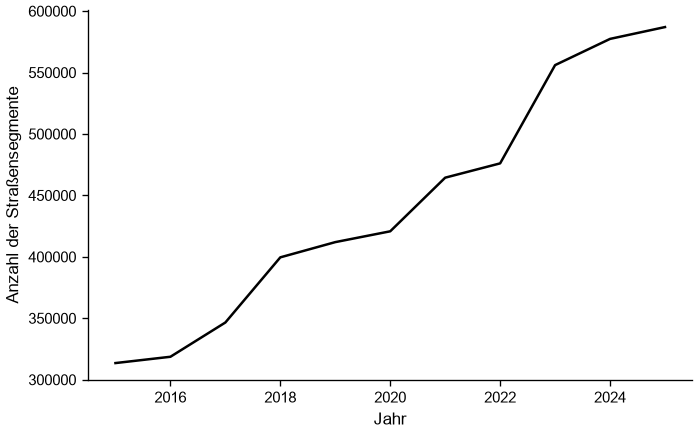

In [3]:
fig, ax = new_figure()
ax.plot(summary.index, summary["street_segments"], label="Straßensegmente", **LINE_KWARGS)
ax.set(xlabel="Jahr", ylabel="Anzahl der Straßensegmente")
save_apa7(fig, "FIG/GIP/figure_1_street_segments_by_year.png")
save_apa7(fig, "FIG/GIP/figure_1_street_segments_by_year.svg")
plt.show()

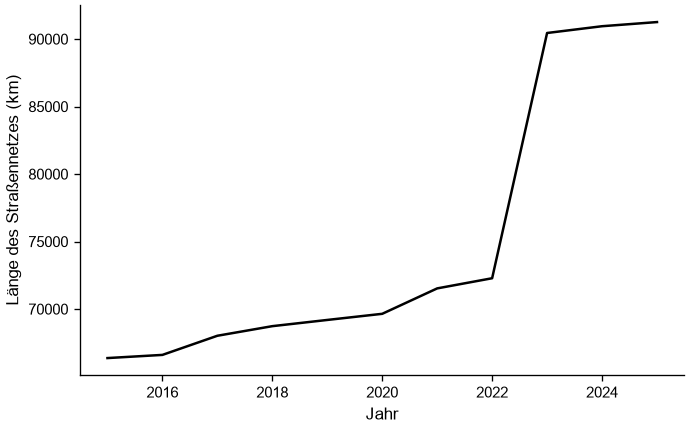

In [4]:
fig, ax = new_figure()
ax.plot(summary.index, summary["network_km"], label="Straßennetz", **LINE_KWARGS)
ax.set(xlabel="Jahr", ylabel="Länge des Straßennetzes (km)")
save_apa7(fig, "FIG/GIP/figure_2_network_length_by_year.png")
save_apa7(fig, "FIG/GIP/figure_2_network_length_by_year.svg")
plt.show()

## Motorway network

Motorway length is shown separately because it is a small share of the total road network.

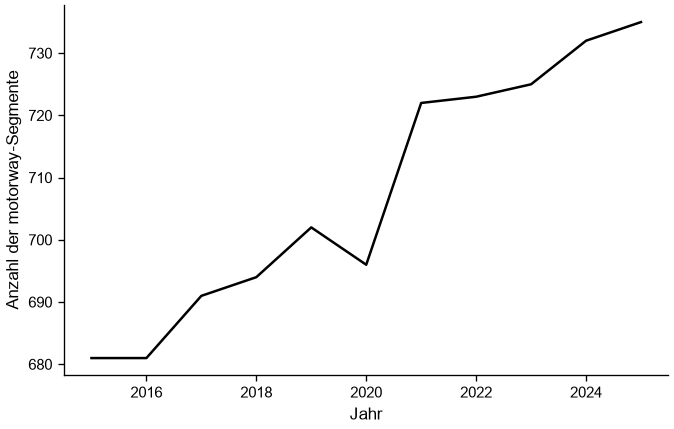

In [5]:
fig, ax = new_figure()
ax.plot(summary.index, summary["motorway_segments"], label="motorway-Segmente", **LINE_KWARGS)
ax.set(xlabel="Jahr", ylabel="Anzahl der motorway-Segmente")
save_apa7(fig, "FIG/GIP/figure_3_motorway_segments_by_year.png")
save_apa7(fig, "FIG/GIP/figure_3_motorway_segments_by_year.svg")
plt.show()

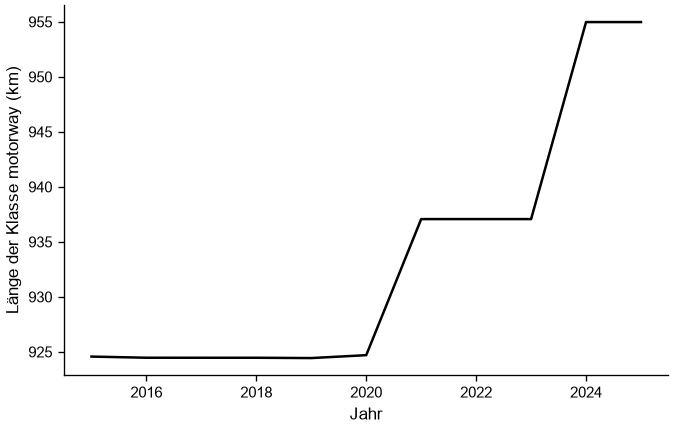

In [6]:
fig, ax = new_figure()
ax.plot(summary.index, summary["motorway_km"], label="motorway", **LINE_KWARGS)
ax.set(xlabel="Jahr", ylabel="Länge der Klasse motorway (km)")
save_apa7(fig, "FIG/GIP/figure_4_motorway_length_by_year.png")
save_apa7(fig, "FIG/GIP/figure_4_motorway_length_by_year.svg")
plt.show()

## Motorway ramp locations

Ramp complexes are derived from the GIP road-line extracts as a network of all `motorway_link` segments. Link endpoints within 10 m are snapped together, allowing multi-link interchange chains. A complex is a candidate when it connects both to a `motorway` and to a non-motorway road; the network direction is used where `oneway=yes` is available, while missing or nonstandard direction tags are treated as bidirectional rather than discarded. A complex may therefore be off-ramp-capable, on-ramp-capable, or both. Its location is clustered with other complexes within 750 m, so one interchange is counted once.

In [7]:
ramp_summary

,off_ramp_complexes,on_ramp_complexes,ramp_locations_750m
year,,,
2015,140,138,83
2016,140,138,84
2017,141,139,84
2018,142,141,85
2019,143,142,85
2020,141,140,84
2021,146,146,87
2022,146,145,87
2023,147,145,87


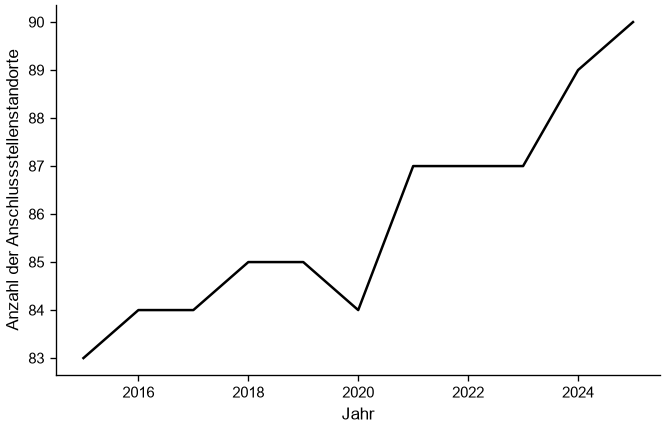

In [8]:
fig, ax = new_figure()
ax.plot(ramp_summary.index, ramp_summary["ramp_locations_750m"], **LINE_KWARGS)
ax.set(xlabel="Jahr", ylabel="Anzahl der Anschlussstellenstandorte")
save_apa7(fig, "FIG/GIP/figure_10_motorway_ramp_locations_by_year.png")
save_apa7(fig, "FIG/GIP/figure_10_motorway_ramp_locations_by_year.svg")
plt.show()

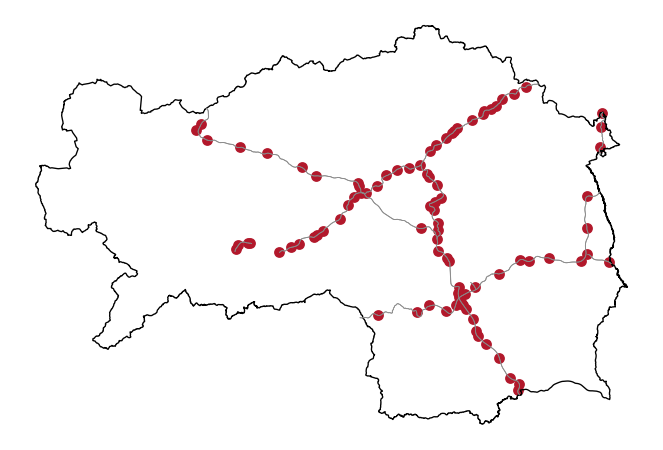

In [9]:
fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
motorway.plot(ax=ax, color="#8a8a8a", linewidth=0.5, rasterized=True)
ramp_locations.plot(ax=ax, color="#b2182b", markersize=30, rasterized=True)
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/GIP/figure_11_motorway_ramp_locations_2025.png")
save_apa7(fig, "FIG/GIP/figure_11_motorway_ramp_locations_2025.svg")
plt.show()

## Motorway ramp-location additions by spatial match

Current ramp locations are grey when they were already spatially observed in 2015 and otherwise coloured by their first observed year. Within each annual snapshot, ramp complexes within 750 m are clustered into one interchange. Across snapshots, the first spatial match is inherited from a ramp location within 1.5 km in any of the preceding three years. This spatial-first rule tolerates identifier changes and construction-related geometry shifts without classifying an existing interchange as new.

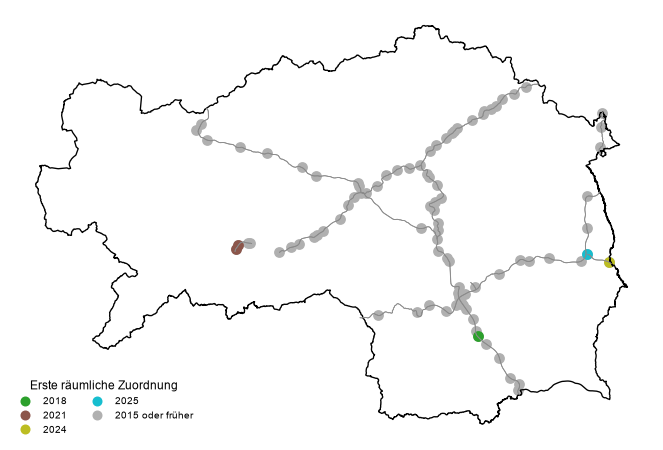

In [10]:
fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
motorway.plot(ax=ax, color="#8a8a8a", linewidth=0.5, rasterized=True)
ramp_locations.plot(ax=ax, color="#b0b0b0", markersize=30, rasterized=True)
addition_years = sorted(int(year) for year in ramp_locations["spatial_first_year"].dropna().unique() if year > 2015)
for year in addition_years:
    year_color = plt.colormaps["tab10"](year - 2016)
    ramp_locations[ramp_locations["spatial_first_year"].eq(year)].plot(ax=ax, color=year_color, markersize=30, rasterized=True)
    ax.plot([], [], marker="o", color=year_color, linestyle="", label=str(year))
ax.plot([], [], marker="o", color="#b0b0b0", linestyle="", label="2015 oder früher")
ax.legend(title="Erste räumliche Zuordnung", ncol=2, loc="lower left", fontsize=6, title_fontsize=7, frameon=False)
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/GIP/figure_12_motorway_ramp_location_additions.png")
save_apa7(fig, "FIG/GIP/figure_12_motorway_ramp_location_additions.svg")
plt.show()

## 

- Grün 2018 Hengsberg  https://www.meinbezirk.at/leibnitz/c-lokales/gruenes-licht-fuer-neue-auf-und-abfahrt-hengsberg-an-der-a9-pyhrn-autobahn_a2708399
- Blau 2024 Knoten Riegersdorf https://steiermark.orf.at/stories/3249983/
- Hellgrün Knoten graz West wurde 2024 saniert nicht gebaut daher zu bereiningen
- Braucn 2021 


## Interactive motorway ramp locations

The Leaflet map provides a zoomable 2025 view of the deduplicated interchange locations.

In [11]:
locations_wgs84 = ramp_locations.to_crs(4326)
html = '''<!doctype html><html><head><meta charset="utf-8"><link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"><script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script><style>#map {height: 720px;}</style></head><body><div id="map"></div><script>const map=L.map("map"); L.tileLayer("https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",{attribution:"© OpenStreetMap contributors"}).addTo(map); const border=L.geoJSON(__BORDER__,{style:{color:"#000",weight:2,fillOpacity:0}}).addTo(map); L.geoJSON(__LOCATIONS__,{pointToLayer:(f,ll)=>L.circleMarker(ll,{radius:7,color:"#b2182b",fillColor:"#b2182b",fillOpacity:.9}),onEachFeature:(f,l)=>l.bindPopup("First spatial observation: "+f.properties.spatial_first_year)}).addTo(map); map.fitBounds(border.getBounds());</script></body></html>'''.replace("__BORDER__", border.to_crs(4326).to_json()).replace("__LOCATIONS__", locations_wgs84.to_json())
interactive_map = Path("FIG/GIP/motorway_ramp_locations_2025_interactive.html")
interactive_map.write_text(html, encoding="utf-8")
interactive_map

WindowsPath('FIG/GIP/motorway_ramp_locations_2025_interactive.html')

## Street network in 2025

The map uses only the dissolved external Styrian border; municipal boundaries are not plotted.

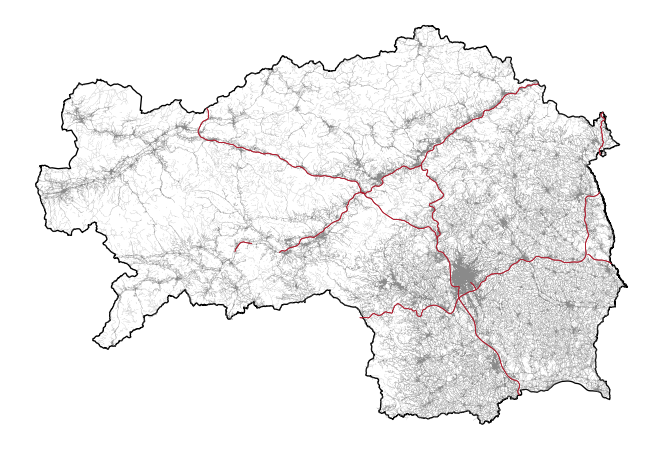

In [12]:
fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
roads.plot(ax=ax, color="#8a8a8a", linewidth=0.08, rasterized=True)
motorway.plot(ax=ax, color="#b2182b", linewidth=0.45, rasterized=True)
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/GIP/figure_5_street_network_2025.png")
save_apa7(fig, "FIG/GIP/figure_5_street_network_2025.svg")
plt.show()

## Street-network additions by data version

All 2025 streets are shown. Grey streets were already present in 2015; colours identify the first version in which a street was observed. The earliest observed year is retained, so later removals do not count as additions.

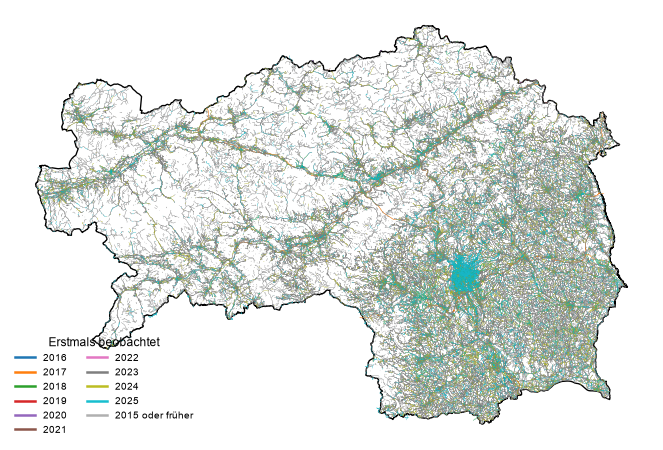

In [13]:
fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
roads.plot(ax=ax, color="#b0b0b0", linewidth=0.08, rasterized=True)
for i, year in enumerate(range(2016, 2026)):
    roads[roads["first_observed_year"].eq(year)].plot(ax=ax, color=plt.colormaps["tab10"](i), linewidth=0.18, rasterized=True)
    ax.plot([], [], color=plt.colormaps["tab10"](i), linewidth=1.5, label=str(year))
ax.plot([], [], color="#b0b0b0", linewidth=1.5, label="2015 oder früher")
ax.legend(title="Erstmals beobachtet", ncol=2, loc="lower left", fontsize=6, title_fontsize=7, frameon=False)
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/GIP/figure_6_street_network_additions.png")
save_apa7(fig, "FIG/GIP/figure_6_street_network_additions.svg")
plt.show()

## Street-network additions by spatial match

This version compares locations rather than OSM identifiers. A segment is treated as already present when its midpoint is within 10 m of a segment observed in an earlier version; this absorbs small geometry changes while flagging sections in genuinely new locations.

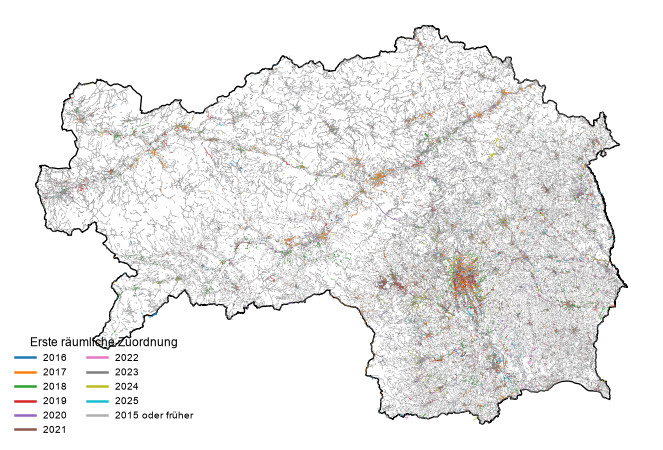

In [14]:
fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
roads.plot(ax=ax, color="#b0b0b0", linewidth=0.08, rasterized=True)
for i, year in enumerate(range(2016, 2026)):
    roads[roads["spatial_first_year"].eq(year)].plot(ax=ax, color=plt.colormaps["tab10"](i), linewidth=0.18, rasterized=True)
    ax.plot([], [], color=plt.colormaps["tab10"](i), linewidth=1.5, label=str(year))
ax.plot([], [], color="#b0b0b0", linewidth=1.5, label="2015 oder früher")
ax.legend(title="Erste räumliche Zuordnung", ncol=2, loc="lower left", fontsize=6, title_fontsize=7, frameon=False)
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/GIP/figure_9_street_network_spatial_additions.png")
save_apa7(fig, "FIG/GIP/figure_9_street_network_spatial_additions.svg")
plt.show()

## Street-network length by road class

Each line gives the total kilometres recorded for an OSM road class in a yearly GIP version.

In [15]:
class_lengths.round(1)

road_class,cycleway,footway,motorway,motorway_link,path,primary,primary_link,residential,secondary,secondary_link,service,steps,tertiary,tertiary_link,track,trunk,trunk_link,unclassified,Total
year,,,,,,,,,,,,,,,,,,,
2015,0.0,33050.2,924.6,232.7,0.0,1232.4,17.1,3208.9,2043.9,15.2,6916.8,0.0,1475.8,12.4,38.4,296.4,4.9,16903.0,66372.8
2016,0.0,33199.7,924.5,232.7,0.0,1229.6,17.1,3274.2,2044.2,15.0,7049.5,0.0,1471.7,12.3,40.8,299.3,4.9,16791.9,66607.5
2017,0.0,34048.9,924.5,233.4,0.1,1234.3,13.6,3567.1,2044.4,14.1,7260.7,0.2,1472.2,10.4,137.8,302.1,4.8,16756.8,68025.3
2018,0.0,34429.3,924.5,234.0,0.0,1241.9,25.7,3926.9,2038.3,19.0,7375.5,0.8,1464.7,12.5,154.3,299.6,7.9,16581.5,68736.5
2019,0.0,34684.2,924.4,233.2,0.0,1242.5,25.4,4099.7,2033.8,18.9,7536.2,3.0,1465.4,12.2,167.2,301.8,8.2,16440.3,69196.4
2020,0.3,34903.7,924.7,233.7,0.0,1242.5,26.3,4158.8,2025.6,18.8,7648.9,3.0,1467.1,12.3,293.4,301.7,8.4,16381.9,69650.9
2021,0.0,36067.9,937.1,236.7,0.0,1076.0,26.1,4287.0,1268.9,30.3,8259.8,3.3,2580.4,17.9,364.8,80.6,2.5,16294.6,71533.8
2022,0.0,36626.6,937.1,236.7,0.0,1080.4,26.8,4326.1,1251.4,30.2,8424.6,3.5,2593.4,18.0,387.3,85.8,2.8,16255.1,72286.1
2023,0.0,54600.5,937.1,243.2,0.0,1081.2,27.2,4377.7,1249.8,30.4,8610.7,3.5,2582.9,17.7,412.0,86.2,3.5,16189.0,90452.6


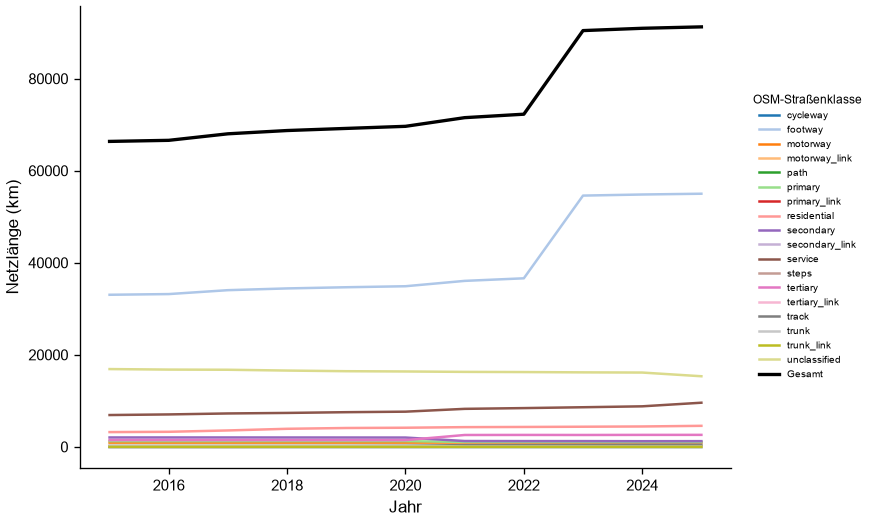

In [16]:
fig, ax = new_figure(7, 5)
for i, road_class in enumerate(class_lengths.columns.drop("Total")):
    ax.plot(class_lengths.index, class_lengths[road_class], color=plt.colormaps["tab20"](i), label=road_class)
ax.plot(class_lengths.index, class_lengths["Total"], color="black", linewidth=2, label="Gesamt")
ax.set(xlabel="Jahr", ylabel="Netzlänge (km)")
ax.legend(title="OSM-Straßenklasse", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=6, title_fontsize=7, frameon=False)
save_apa7(fig, "FIG/GIP/figure_7_network_length_by_road_class.png")
save_apa7(fig, "FIG/GIP/figure_7_network_length_by_road_class.svg")
plt.show()

## Road hierarchy in 2025

This additional view shows which OSM road classes account for the largest share of the mapped network length.

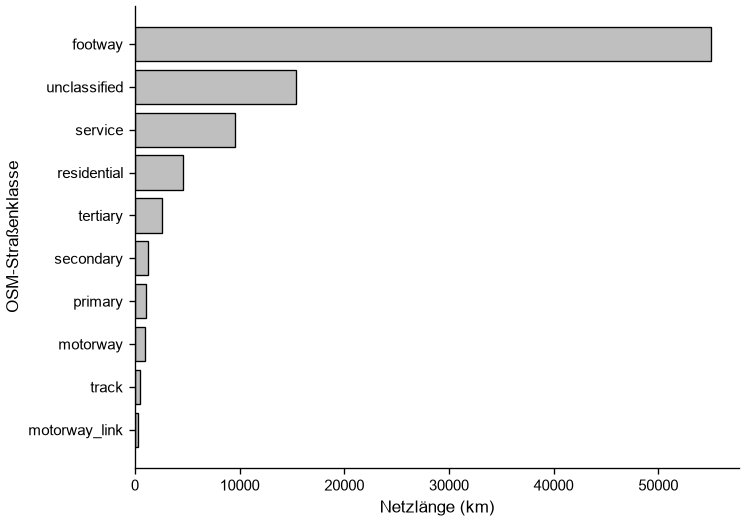

In [17]:
classes = roads.groupby("highway").km.sum().sort_values().tail(10)
fig, ax = new_figure(6.5, 5)
ax.barh(classes.index, classes.values, **BAR_KWARGS)
ax.set(xlabel="Netzlänge (km)", ylabel="OSM-Straßenklasse")
save_apa7(fig, "FIG/GIP/figure_8_road_classes_2025.png")
save_apa7(fig, "FIG/GIP/figure_8_road_classes_2025.svg")
plt.show()